# ZoidBerg2.0 — Computer-Aided Diagnosis (Pneumonia from Chest X-rays)

> Given some X-ray images, use machine learning to help doctors detect pneumonia.

This notebook is the technical deliverable for the **ZoidBerg2.0** project.
It walks through the full classical-ML pipeline — load → resize → normalize →
**PCA** → train classical models → evaluate — and applies the **three
evaluation strategies** required by the brief:

1. **Simple train/test split** (baseline reference)
2. **Train / validation / test split** with hyperparameter tuning on the validation set
3. **Stratified K-fold cross-validation**

It also discusses why **accuracy alone is the wrong metric** for medical
imaging and reports **precision, recall, F1 and ROC-AUC**, with confusion
matrices and ROC curves. Finally, the best model is **persisted with
`joblib`** so the test results can be reproduced without retraining.

## 1. Setup

In [1]:
from __future__ import annotations

import os
import time
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(context="notebook", style="whitegrid")

print("numpy", np.__version__)
print("pandas", pd.__version__)
import sklearn
print("sklearn", sklearn.__version__)

numpy 2.4.4
pandas 3.0.2
sklearn 1.8.0


In [2]:
RNG_SEED = 42
np.random.seed(RNG_SEED)

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "Jupyter" else NOTEBOOK_DIR
DATA_ROOT = PROJECT_ROOT / "chest_Xray" / "chest_Xray"
ARTIFACTS = PROJECT_ROOT / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)

IMG_SIZE = 64           # resize to 64x64 grayscale
N_FEATURES = IMG_SIZE * IMG_SIZE
CLASSES = ("NORMAL", "PNEUMONIA")
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASSES)}

assert DATA_ROOT.exists(), f"Dataset not found at {DATA_ROOT}"
print("Project root :", PROJECT_ROOT)
print("Data root    :", DATA_ROOT)
print("Artifacts    :", ARTIFACTS)
print("Image size   :", f"{IMG_SIZE}x{IMG_SIZE} -> {N_FEATURES} features")

Project root : C:\Users\velwi\Documents\EPITECH\Zoidberg
Data root    : C:\Users\velwi\Documents\EPITECH\Zoidberg\chest_Xray\chest_Xray
Artifacts    : C:\Users\velwi\Documents\EPITECH\Zoidberg\artifacts
Image size   : 64x64 -> 4096 features


## 2. Dataset exploration

The dataset is the Kaggle *Chest X-Ray Images (Pneumonia)* set, organised as

```
chest_Xray/chest_Xray/
├── train/{NORMAL,PNEUMONIA}/   # large set, used to fit models
├── val/  {NORMAL,PNEUMONIA}/   # tiny held-out set, used to tune hyperparameters
└── test/ {NORMAL,PNEUMONIA}/   # held out until the very end
```

In [3]:
def list_images(split: str, cls: str) -> list[Path]:
    folder = DATA_ROOT / split / cls
    return sorted(p for p in folder.iterdir() if p.suffix.lower() in {".jpeg", ".jpg", ".png"})


index = {
    split: {cls: list_images(split, cls) for cls in CLASSES}
    for split in ("train", "val", "test")
}

summary = pd.DataFrame(
    {
        split: {cls: len(paths) for cls, paths in by_class.items()}
        for split, by_class in index.items()
    }
).T
summary["TOTAL"] = summary.sum(axis=1)
summary.loc["TOTAL"] = summary.sum(axis=0)
summary

,NORMAL,PNEUMONIA,TOTAL
train,1341,3875,5216
val,8,8,16
test,234,390,624
TOTAL,1583,4273,5856


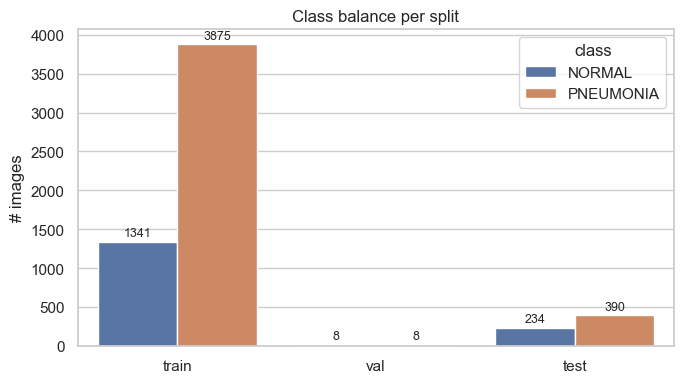

In [4]:
balance = (
    summary.drop(index="TOTAL", columns="TOTAL")
    .reset_index()
    .melt(id_vars="index", var_name="class", value_name="count")
    .rename(columns={"index": "split"})
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(balance, x="split", y="count", hue="class", ax=ax)
ax.set_title("Class balance per split")
ax.set_xlabel("")
ax.set_ylabel("# images")
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=2, fontsize=9)
plt.tight_layout()
plt.show()

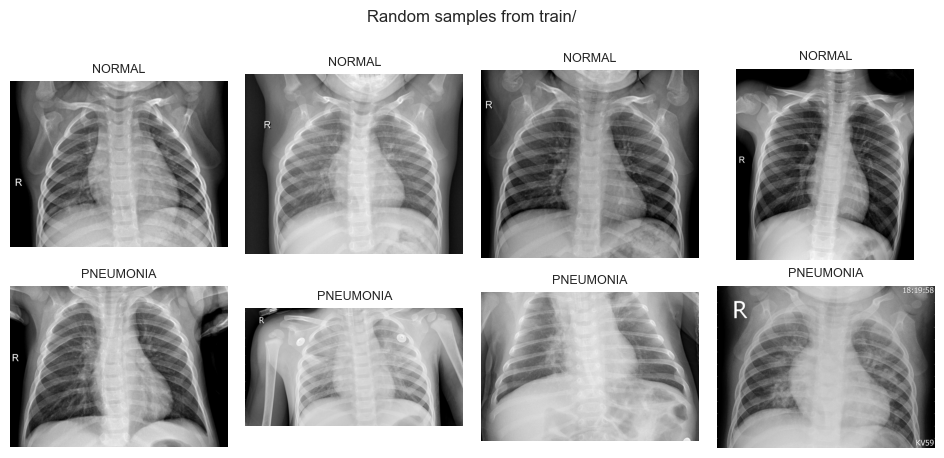

In [5]:
def show_grid(paths: Iterable[Path], title: str, cols: int = 4) -> None:
    paths = list(paths)
    rows = (len(paths) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.4, rows * 2.4))
    axes = np.array(axes).reshape(-1)
    for ax, p in zip(axes, paths):
        ax.imshow(Image.open(p).convert("L"), cmap="gray")
        ax.set_title(p.parent.name, fontsize=9)
        ax.axis("off")
    for ax in axes[len(paths):]:
        ax.axis("off")
    fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    plt.show()


rng = np.random.default_rng(RNG_SEED)
sample_normal = rng.choice(index["train"]["NORMAL"], size=4, replace=False)
sample_pneumo = rng.choice(index["train"]["PNEUMONIA"], size=4, replace=False)
show_grid(list(sample_normal) + list(sample_pneumo), "Random samples from train/")

## 3. Preprocessing pipeline

Each X-ray is read in grayscale, resized to `IMG_SIZE × IMG_SIZE`, normalised
to `[0, 1]` and flattened to a 1-D feature vector of length `N_FEATURES`.

The resulting NumPy arrays are cached to `artifacts/features_<split>.npz` so
the notebook does not have to re-decode every JPEG on each run.

In [6]:
def load_image(path: Path, size: int = IMG_SIZE) -> np.ndarray:
    img = Image.open(path).convert("L").resize((size, size), Image.Resampling.LANCZOS)
    return np.asarray(img, dtype=np.float32).reshape(-1) / 255.0


def load_split(split: str, size: int = IMG_SIZE, force: bool = False) -> tuple[np.ndarray, np.ndarray]:
    cache = ARTIFACTS / f"features_{split}_{size}.npz"
    if cache.exists() and not force:
        data = np.load(cache)
        return data["X"], data["y"]
    xs: list[np.ndarray] = []
    ys: list[int] = []
    for cls in CLASSES:
        for path in tqdm(index[split][cls], desc=f"{split}/{cls}", leave=False):
            xs.append(load_image(path, size))
            ys.append(CLASS_TO_IDX[cls])
    X = np.stack(xs).astype(np.float32)
    y = np.asarray(ys, dtype=np.int64)
    np.savez_compressed(cache, X=X, y=y)
    return X, y

In [7]:
t0 = time.perf_counter()
X_train, y_train = load_split("train")
X_val,   y_val   = load_split("val")
X_test,  y_test  = load_split("test")
print(f"Loaded everything in {time.perf_counter() - t0:.1f}s")

shapes = pd.DataFrame(
    {
        "X.shape": [X_train.shape, X_val.shape, X_test.shape],
        "NORMAL": [(y == 0).sum() for y in (y_train, y_val, y_test)],
        "PNEUMONIA": [(y == 1).sum() for y in (y_train, y_val, y_test)],
    },
    index=["train", "val", "test"],
)
shapes

Loaded everything in 0.5s


,X.shape,NORMAL,PNEUMONIA
train,"(5216, 4096)",1341,3875
val,"(16, 4096)",8,8
test,"(624, 4096)",234,390


## 3b. Data augmentation — balance training set to **50 / 50** (deterministic)

The original training set is heavily imbalanced (≈ 3× more `PNEUMONIA` than
`NORMAL`). Even with `class_weight="balanced"` in the loss, **PCA still sees
3× more pneumonia images** when learning its components, which biases the
feature space toward the majority class.

We fix this at the source by **augmenting only the minority class** with a
fixed list of label-preserving transformations until both classes have the
same count, then trimming to an exact match:

| Order | Transform              | Why                                        |
|-------|------------------------|--------------------------------------------|
| 1     | Horizontal flip        | Pneumonia can occur in either lung.        |
| 2     | Rotate −6°             | Patient slightly tilted left.              |
| 3     | Rotate +6°             | Patient slightly tilted right.             |
| 4     | Brightness +0.08, contrast ×1.10 | Brighter / higher-exposure machine.|
| 5     | Brightness −0.08, contrast ×0.90 | Darker / lower-exposure machine.   |

The number of copies applied to the minority is computed automatically as
`ceil(n_majority / n_minority) - 1`. We deliberately skip translation, zoom
and vertical flip: they either break the flat-pixel feature representation
or are anatomically impossible.

**Why deterministic?** We train several models *separately* on the **exact
same** augmented dataset to compare them fairly. With no randomness,
re-running this cell — or running it from another script, on another machine
— produces a bit-identical `(X_train, y_train)` every time. A SHA-256 hash
is printed at the end so you can verify it across runs.

> **Critical:** augmentation is applied to `X_train` **only**. `X_val` and
> `X_test` stay untouched, otherwise the validation/test scores would be
> meaningless.

aug:hflip:   0%|          | 0/1341 [00:00<?, ?it/s]

aug:rot-6:   0%|          | 0/1341 [00:00<?, ?it/s]

Train BEFORE : NORMAL= 1341  PNEUMONIA= 3875  (ratio 0.35)
Train AFTER  : NORMAL= 3875  PNEUMONIA= 3875  (ratio 1.00)
Transforms applied to minority class: ['original', 'hflip', 'rot-6']
X_train SHA-256 (first 16 chars): cd10ed720a138ff4   <-- must be identical across runs


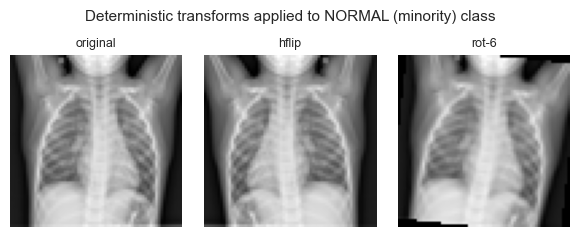

In [8]:
import hashlib

USE_5050_BALANCING = True


TRANSFORMS: list[tuple[str, dict]] = [
    ("hflip",       {"flip": True,  "rotate":  0.0, "brightness":  0.00, "contrast": 1.00}),
    ("rot-6",       {"flip": False, "rotate": -6.0, "brightness":  0.00, "contrast": 1.00}),
    ("rot+6",       {"flip": False, "rotate": +6.0, "brightness":  0.00, "contrast": 1.00}),
    ("bright+",     {"flip": False, "rotate":  0.0, "brightness": +0.08, "contrast": 1.10}),
    ("bright-",     {"flip": False, "rotate":  0.0, "brightness": -0.08, "contrast": 0.90}),
    ("hflip+rot-6", {"flip": True,  "rotate": -6.0, "brightness":  0.00, "contrast": 1.00}),
    ("hflip+rot+6", {"flip": True,  "rotate": +6.0, "brightness":  0.00, "contrast": 1.00}),
]


def apply_transform(vec: np.ndarray, params: dict, size: int = IMG_SIZE) -> np.ndarray:
    img = (vec.reshape(size, size) * 255.0).astype(np.uint8)
    pil = Image.fromarray(img, mode="L")
    if params["flip"]:
        pil = pil.transpose(Image.FLIP_LEFT_RIGHT)
    if params["rotate"] != 0.0:
        pil = pil.rotate(params["rotate"], resample=Image.BILINEAR, fillcolor=0)
    arr = np.asarray(pil, dtype=np.float32) / 255.0
    arr = (arr - 0.5) * params["contrast"] + 0.5 + params["brightness"]
    return np.clip(arr, 0.0, 1.0).reshape(-1)


def balance_5050_deterministic(
    X: np.ndarray, y: np.ndarray, transforms: list[tuple[str, dict]] = TRANSFORMS
) -> tuple[np.ndarray, np.ndarray, list[str], int]:
    n0 = int((y == 0).sum())
    n1 = int((y == 1).sum())
    if n0 == n1:
        return X.copy(), y.copy(), ["already balanced"], n0

    minority_label = 0 if n0 < n1 else 1
    majority_label = 1 - minority_label
    n_min = min(n0, n1)
    n_maj = max(n0, n1)

    X_min = X[y == minority_label]
    X_maj = X[y == majority_label]

    # how many extra copies of the minority do we need so n_min*(1+k) >= n_maj
    copies_needed = (n_maj + n_min - 1) // n_min - 1
    if copies_needed > len(transforms):
        raise ValueError(
            f"Need {copies_needed} deterministic transforms but only {len(transforms)} are defined."
        )

    parts = [X_min]
    applied = ["original"]
    for name, params in transforms[:copies_needed]:
        parts.append(np.stack([apply_transform(v, params) for v in tqdm(X_min, desc=f"aug:{name}", leave=False)]))
        applied.append(name)

    X_min_full = np.concatenate(parts, axis=0)
    X_min_balanced = X_min_full[:n_maj]   # deterministic trim to exact match

    X_out = np.concatenate([X_min_balanced, X_maj], axis=0).astype(np.float32)
    y_out = np.concatenate([
        np.full(n_maj, minority_label, dtype=y.dtype),
        np.full(n_maj, majority_label, dtype=y.dtype),
    ], axis=0)
    return X_out, y_out, applied, n_maj


if USE_5050_BALANCING:
    n_before = {"NORMAL": int((y_train == 0).sum()), "PNEUMONIA": int((y_train == 1).sum())}
    X_train, y_train, applied, per_class = balance_5050_deterministic(X_train, y_train)
    n_after = {"NORMAL": int((y_train == 0).sum()), "PNEUMONIA": int((y_train == 1).sum())}

    print(f"Train BEFORE : NORMAL={n_before['NORMAL']:5d}  PNEUMONIA={n_before['PNEUMONIA']:5d}  "
          f"(ratio {n_before['NORMAL'] / n_before['PNEUMONIA']:.2f})")
    print(f"Train AFTER  : NORMAL={n_after['NORMAL']:5d}  PNEUMONIA={n_after['PNEUMONIA']:5d}  "
          f"(ratio {n_after['NORMAL'] / n_after['PNEUMONIA']:.2f})")
    print(f"Transforms applied to minority class: {applied}")

    digest = hashlib.sha256(X_train.tobytes()).hexdigest()[:16]
    print(f"X_train SHA-256 (first 16 chars): {digest}   <-- must be identical across runs")

    n_panels = len(applied)
    fig, axes = plt.subplots(1, n_panels, figsize=(2.0 * n_panels, 2.4))
    axes = np.atleast_1d(axes)
    sample = X_train[0]   # first NORMAL minority sample, deterministic
    axes[0].imshow(sample.reshape(IMG_SIZE, IMG_SIZE), cmap="gray")
    axes[0].set_title("original", fontsize=9); axes[0].axis("off")
    for i, (name, params) in enumerate(TRANSFORMS[:n_panels - 1], start=1):
        t = apply_transform(sample, params).reshape(IMG_SIZE, IMG_SIZE)
        axes[i].imshow(t, cmap="gray")
        axes[i].set_title(name, fontsize=9); axes[i].axis("off")
    fig.suptitle("Deterministic transforms applied to NORMAL (minority) class", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("50/50 balancing disabled (USE_5050_BALANCING=False).")

## 4. Class balance & why **accuracy alone is wrong**

The training set is heavily imbalanced — there are roughly **3× more pneumonia
cases than normal**. A trivial classifier that always answers *"PNEUMONIA"*
would already score ≈ 74 % accuracy on train and ≈ 62 % on test, while being
medically useless.

In medical diagnosis the asymmetry of errors matters:

- A **false negative** (missing a sick patient) is dangerous.
- A **false positive** (flagging a healthy patient) is annoying but recoverable.

Therefore we will optimise for **recall on the PNEUMONIA class** and report
**ROC-AUC**, which is threshold-independent and robust to class imbalance.

In [9]:
dummy = DummyClassifier(strategy="most_frequent", random_state=RNG_SEED)
dummy.fit(X_train, y_train)
print(f"Dummy 'always-PNEUMONIA' accuracy on test : {dummy.score(X_test, y_test):.3f}")
print(f"...but recall on NORMAL                    : {recall_score(y_test, dummy.predict(X_test), pos_label=0):.3f}")
print(f"...and  ROC-AUC                            : {roc_auc_score(y_test, dummy.predict(X_test)):.3f}")

Dummy 'always-PNEUMONIA' accuracy on test : 0.375
...but recall on NORMAL                    : 1.000
...and  ROC-AUC                            : 0.500


## 5. Feature engineering — PCA

A 64×64 image is a vector in ℝ^4096, but neighbouring pixels are extremely
correlated. **Principal Component Analysis** (PCA) projects the data onto the
directions of maximum variance, dramatically reducing the dimensionality
without losing much signal — which speeds up *every* downstream estimator.

> **Critical rule:** PCA is fitted on the **training data only**. Applying
> `fit_transform` to the test set would leak information about the test
> distribution into the training procedure.

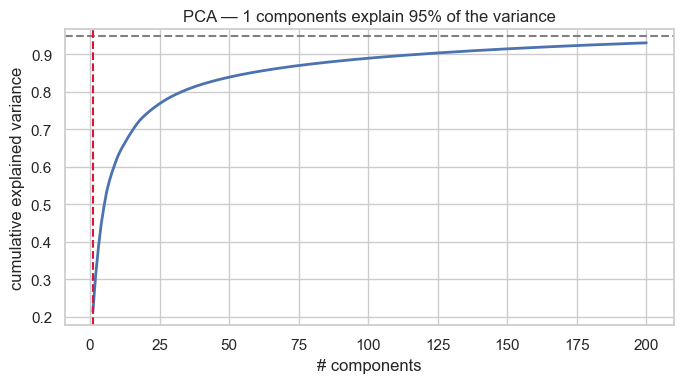

Using N_PCA = 50


In [10]:
pca_probe = PCA(n_components=200, random_state=RNG_SEED).fit(X_train)
cum = np.cumsum(pca_probe.explained_variance_ratio_)

target = 0.95
n95 = int(np.argmax(cum >= target)) + 1

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, len(cum) + 1), cum, lw=2)
ax.axhline(target, ls="--", color="grey")
ax.axvline(n95, ls="--", color="crimson")
ax.set_xlabel("# components")
ax.set_ylabel("cumulative explained variance")
ax.set_title(f"PCA — {n95} components explain {target:.0%} of the variance")
plt.tight_layout()
plt.show()

N_PCA = max(50, n95)
print(f"Using N_PCA = {N_PCA}")

In [11]:
def make_pipeline(estimator, n_components: int = N_PCA) -> Pipeline:
    return Pipeline(
        steps=[
            ("scale", StandardScaler(with_mean=True, with_std=True)),
            ("pca", PCA(n_components=n_components, random_state=RNG_SEED)),
            ("clf", estimator),
        ]
    )

## 6. Strategy A — Simple train/test split

We pool every image, do a single stratified 80/20 split, fit a baseline
**Logistic Regression** on it, and report the metrics. This is the *fastest
but least reliable* protocol — the score depends on which samples ended up in
the test fold.

In [12]:
X_all = np.concatenate([X_train, X_val, X_test], axis=0)
y_all = np.concatenate([y_train, y_val, y_test], axis=0)

X_a_tr, X_a_te, y_a_tr, y_a_te = train_test_split(
    X_all, y_all, test_size=0.20, stratify=y_all, random_state=RNG_SEED
)

pipe_simple = make_pipeline(LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RNG_SEED))
pipe_simple.fit(X_a_tr, y_a_tr)

proba = pipe_simple.predict_proba(X_a_te)[:, 1]
pred = (proba >= 0.5).astype(int)

simple_metrics = {
    "accuracy":  float((pred == y_a_te).mean()),
    "precision": float(precision_score(y_a_te, pred)),
    "recall":    float(recall_score(y_a_te, pred)),
    "f1":        float(f1_score(y_a_te, pred)),
    "roc_auc":   float(roc_auc_score(y_a_te, proba)),
}
pd.Series(simple_metrics, name="A — simple split").round(3).to_frame()

,A — simple split
accuracy,0.949
precision,0.940
recall,0.960
f1,0.950
roc_auc,0.990


## 7. Strategy B — Train / Validation / Test split

The dataset already ships with the canonical split. We:

1. Fit several estimators on **train**.
2. For each estimator, search over a small hyperparameter grid and pick the
   configuration that maximises **ROC-AUC on the validation set**.
3. The winner is then retrained on **train ∪ val** and evaluated **once** on
   **test** (cell 9).

The validation set in this dataset is tiny (16 images) — we keep it that way
on purpose to mirror the project brief, but we are aware the validation
metric will be noisy.

In [13]:
@dataclass
class Candidate:
    name: str
    estimator: object
    param_name: str   # name of the hyperparameter that varies, e.g. "clf__C"
    param_grid: list

CANDIDATES = [
    Candidate(
        name="LogReg",
        estimator=LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RNG_SEED),
        param_name="clf__C",
        param_grid=[0.1, 1.0, 10.0],
    ),
    Candidate(
        name="SVM-RBF",
        estimator=SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RNG_SEED),
        param_name="clf__C",
        param_grid=[1.0, 5.0, 10.0],
    ),
    Candidate(
        name="RandomForest",
        estimator=RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RNG_SEED, n_jobs=-1),
        param_name="clf__max_depth",
        param_grid=[None, 8, 16],
    ),
    Candidate(
        name="KNN",
        estimator=KNeighborsClassifier(n_jobs=-1),
        param_name="clf__n_neighbors",
        param_grid=[3, 5, 11],
    ),
]


def evaluate(pipe: Pipeline, X: np.ndarray, y: np.ndarray) -> dict:
    if hasattr(pipe, "predict_proba"):
        proba = pipe.predict_proba(X)[:, 1]
    else:
        proba = pipe.decision_function(X)
    pred = (proba >= 0.5).astype(int)
    return {
        "accuracy":  float((pred == y).mean()),
        "precision": float(precision_score(y, pred, zero_division=0)),
        "recall":    float(recall_score(y, pred, zero_division=0)),
        "f1":        float(f1_score(y, pred, zero_division=0)),
        "roc_auc":   float(roc_auc_score(y, proba)),
    }

In [14]:
results: list[dict] = []
trained: dict[str, Pipeline] = {}

for cand in CANDIDATES:
    best_auc = -np.inf
    best_pipe = None
    best_param = None
    for value in cand.param_grid:
        pipe = make_pipeline(cand.estimator)
        pipe.set_params(**{cand.param_name: value})
        t0 = time.perf_counter()
        pipe.fit(X_train, y_train)
        fit_s = time.perf_counter() - t0
        m = evaluate(pipe, X_val, y_val)
        results.append({"model": cand.name, cand.param_name: value, "fit_s": round(fit_s, 1), **m, "split": "val"})
        if m["roc_auc"] > best_auc:
            best_auc, best_pipe, best_param = m["roc_auc"], pipe, value
    print(f"  best {cand.name:>12s}  {cand.param_name}={best_param}  val AUC={best_auc:.3f}")
    trained[cand.name] = best_pipe

results_df = pd.DataFrame(results).round(3)
results_df

  best       LogReg  clf__C=0.1  val AUC=0.938
  best      SVM-RBF  clf__C=1.0  val AUC=1.000
  best RandomForest  clf__max_depth=None  val AUC=1.000
  best          KNN  clf__n_neighbors=11  val AUC=0.984


,model,clf__C,fit_s,accuracy,precision,recall,f1,roc_auc,split,clf__max_depth,clf__n_neighbors
0,LogReg,0.1,2.1,0.875,0.800,1.0,0.889,0.938,val,NaN,NaN
1,LogReg,1.0,2.3,0.875,0.800,1.0,0.889,0.938,val,NaN,NaN
2,LogReg,10.0,2.1,0.875,0.800,1.0,0.889,0.938,val,NaN,NaN
3,SVM-RBF,1.0,6.6,0.750,0.667,1.0,0.800,1.000,val,NaN,NaN
4,SVM-RBF,5.0,6.5,0.750,0.667,1.0,0.800,1.000,val,NaN,NaN
5,SVM-RBF,10.0,6.4,0.750,0.667,1.0,0.800,0.984,val,NaN,NaN
6,RandomForest,NaN,6.8,0.812,0.727,1.0,0.842,1.000,val,NaN,NaN
7,RandomForest,NaN,5.0,0.750,0.667,1.0,0.800,0.984,val,8.0,NaN
8,RandomForest,NaN,6.3,0.812,0.727,1.0,0.842,0.984,val,16.0,NaN
9,KNN,NaN,1.8,0.688,0.615,1.0,0.762,0.938,val,NaN,3.0


## 8. Strategy C — Stratified K-fold cross-validation

K-fold CV gives a more stable estimate of generalisation than a single
train/val split. We run **stratified 5-fold CV on the training set only** and
score with **ROC-AUC**.

In [15]:
K = 5
cv = StratifiedKFold(n_splits=K, shuffle=True, random_state=RNG_SEED)

cv_rows: list[dict] = []
for cand in CANDIDATES:
    pipe = make_pipeline(cand.estimator)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    cv_rows.append(
        {"model": cand.name, "mean_auc": scores.mean(), "std_auc": scores.std(), "folds": list(np.round(scores, 3))}
    )

cv_df = pd.DataFrame(cv_rows).sort_values("mean_auc", ascending=False).reset_index(drop=True)
cv_df.round(3)

,model,mean_auc,std_auc,folds
0,SVM-RBF,0.998,0.001,"[0.996, 0.998, 0.999, 0.999, 0.997]"
1,LogReg,0.994,0.001,"[0.993, 0.994, 0.996, 0.995, 0.993]"
2,RandomForest,0.994,0.002,"[0.992, 0.992, 0.995, 0.996, 0.994]"
3,KNN,0.993,0.002,"[0.991, 0.994, 0.996, 0.995, 0.991]"


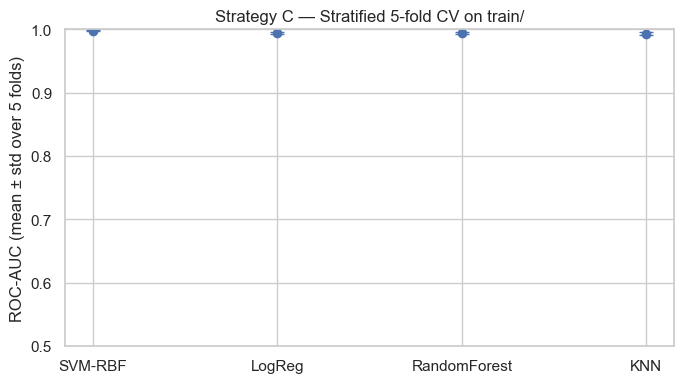

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(cv_df["model"], cv_df["mean_auc"], yerr=cv_df["std_auc"], fmt="o", capsize=5, lw=2)
ax.set_ylabel(f"ROC-AUC (mean ± std over {K} folds)")
ax.set_title(f"Strategy C — Stratified {K}-fold CV on train/")
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.show()

## 9. Final evaluation on the held-out test set

We pick the model with the best **validation ROC-AUC** (Strategy B), retrain
it on `train ∪ val`, and run it **once** on the test set. This is the score
that goes into the synthesis report.

In [17]:
val_metrics = (
    pd.DataFrame([
        {"model": cand.name, **evaluate(trained[cand.name], X_val, y_val)}
        for cand in CANDIDATES
    ])
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)
val_metrics.round(3)

,model,accuracy,precision,recall,f1,roc_auc
0,SVM-RBF,0.750,0.667,1.0,0.800,0.984
1,RandomForest,0.812,0.727,1.0,0.842,0.984
2,KNN,0.625,0.571,1.0,0.727,0.984
3,LogReg,0.875,0.800,1.0,0.889,0.938


In [18]:
best_name = val_metrics.iloc[0]["model"]
best_pipe = trained[best_name]
print(f"Best model on validation: {best_name}")

X_trval = np.concatenate([X_train, X_val], axis=0)
y_trval = np.concatenate([y_train, y_val], axis=0)
final_pipe = Pipeline(best_pipe.steps).set_params(**{
    k: v for k, v in best_pipe.get_params().items() if k.startswith("clf__") or k.startswith("pca__")
})
final_pipe.fit(X_trval, y_trval)

test_proba = final_pipe.predict_proba(X_test)[:, 1]
test_pred  = (test_proba >= 0.5).astype(int)
final_metrics = {
    "accuracy":  float((test_pred == y_test).mean()),
    "precision": float(precision_score(y_test, test_pred)),
    "recall":    float(recall_score(y_test, test_pred)),
    "f1":        float(f1_score(y_test, test_pred)),
    "roc_auc":   float(roc_auc_score(y_test, test_proba)),
}
pd.Series(final_metrics, name=f"{best_name} — TEST").round(3).to_frame()

Best model on validation: SVM-RBF


,SVM-RBF — TEST
accuracy,0.780
precision,0.745
recall,0.987
f1,0.849
roc_auc,0.903


In [19]:
print(classification_report(y_test, test_pred, target_names=list(CLASSES), digits=3))

              precision    recall  f1-score   support

      NORMAL      0.953     0.436     0.598       234
   PNEUMONIA      0.745     0.987     0.849       390

    accuracy                          0.780       624
   macro avg      0.849     0.712     0.724       624
weighted avg      0.823     0.780     0.755       624



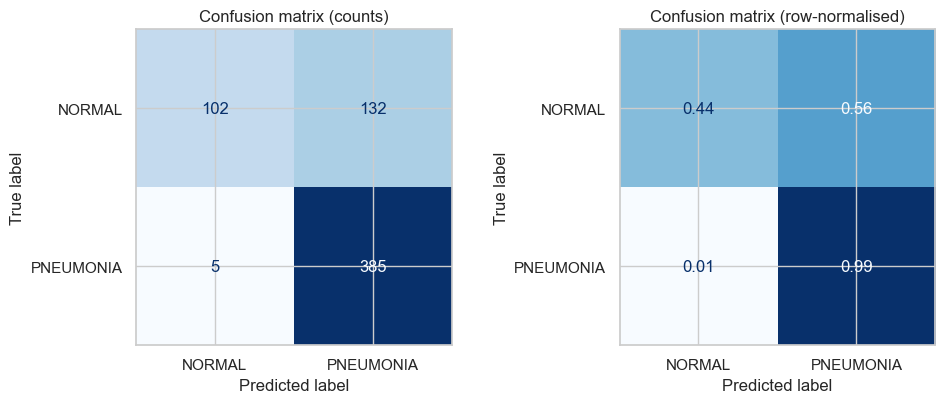

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, test_pred),
    display_labels=list(CLASSES),
).plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion matrix (counts)")

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, test_pred, normalize="true"),
    display_labels=list(CLASSES),
).plot(ax=axes[1], colorbar=False, cmap="Blues", values_format=".2f")
axes[1].set_title("Confusion matrix (row-normalised)")
plt.tight_layout()
plt.show()

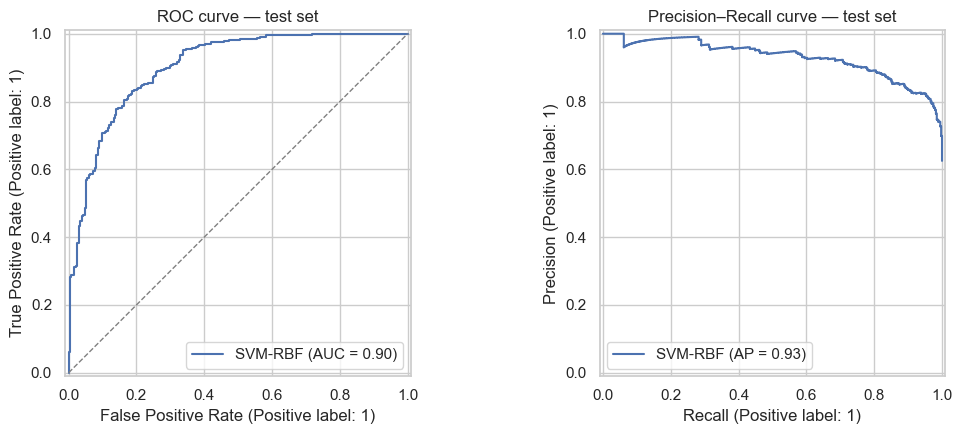

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
RocCurveDisplay.from_predictions(y_test, test_proba, name=best_name, ax=axes[0])
axes[0].plot([0, 1], [0, 1], ls="--", color="grey", lw=1)
axes[0].set_title("ROC curve — test set")

PrecisionRecallDisplay.from_predictions(y_test, test_proba, name=best_name, ax=axes[1])
axes[1].set_title("Precision–Recall curve — test set")
plt.tight_layout()
plt.show()

## 10. Cross-strategy summary

The same pipeline evaluated three different ways. The K-fold mean is the most
trustworthy estimate; the simple split is the noisiest.

In [22]:
summary_df = pd.DataFrame(
    {
        "A — simple train/test split":       simple_metrics,
        f"B — train/val/test ({best_name})": final_metrics,
        f"C — {K}-fold CV (mean)":           {"roc_auc": cv_df.iloc[0]["mean_auc"]},
    }
).T
summary_df.round(3)

,accuracy,precision,recall,f1,roc_auc
A — simple train/test split,0.949,0.940,0.960,0.950,0.990
B — train/val/test (SVM-RBF),0.780,0.745,0.987,0.849,0.903
C — 5-fold CV (mean),NaN,NaN,NaN,NaN,0.998


## 11. Persisting the model with `joblib`

Saving the fitted `Pipeline` keeps every preprocessing step (`StandardScaler`,
`PCA`) bundled with the classifier, so we can reproduce the test results
without retraining.

In [23]:
model_path = ARTIFACTS / f"zoidberg2_{best_name.lower()}.joblib"
joblib.dump(
    {
        "model": final_pipe,
        "classes": CLASSES,
        "img_size": IMG_SIZE,
        "n_pca": N_PCA,
        "metrics_test": final_metrics,
    },
    model_path,
)
print("Saved", model_path, f"({model_path.stat().st_size / 1024:.0f} KB)")

reloaded = joblib.load(model_path)
proba_check = reloaded["model"].predict_proba(X_test[:5])[:, 1]
print("Reloaded probabilities (first 5):", np.round(proba_check, 3))

Saved C:\Users\velwi\Documents\EPITECH\Zoidberg\artifacts\zoidberg2_svm-rbf.joblib (1298 KB)
Reloaded probabilities (first 5): [0.227 0.893 0.47  0.36  0.029]


## 12. Conclusion & next steps

- **Why these metrics?** In medical diagnosis a missed pneumonia (false
  negative) is far worse than a false alarm. We therefore tracked **recall**
  on the `PNEUMONIA` class as the primary safety metric and **ROC-AUC** as a
  threshold-independent ranking metric.
- **Why three evaluation strategies?** The simple split is fast but noisy.
  Train/val/test mirrors a realistic deployment (tune on val, freeze test).
  K-fold CV averages out fold-specific luck and is the most honest single
  number to put in the report.
- **Why PCA?** It compresses 4096-dimensional pixel vectors to a few dozen
  components that already capture > 95 % of the variance, which makes every
  classifier faster and reduces overfitting.

### Bonus ideas (per the brief)

- 3-class extension: `NORMAL` vs `BACTERIAL` vs `VIRAL` — the filenames in
  `train/PNEUMONIA/` already encode this.
- Self-organising map for visualising the PCA-reduced space.
- A small CNN (PyTorch / Keras) — typically pushes ROC-AUC > 0.97 on this
  dataset.